### Loading the Squad 200 experimental Dataset

In [ ]:
import json

#FILE_PATH = "/content/drive/MyDrive/Poster Presentation/squad_200_experimental_data.jsonl"
FILE_PATH="/content/drive/MyDrive/poster presentation/squad_200_experimental_data.jsonl"

experimental_data = []

with open(FILE_PATH, "r", encoding="utf-8") as file:
    for line in file:
        example = json.loads(line)
        experimental_data.append(example)

print("Loaded examples:", len(experimental_data))

Loaded examples: 200


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
print(experimental_data[0])

{'id': '57296a65af94a219006aa3c5', 'title': 'Chloroplast', 'question': 'How does the secondary theory say most cpDNA is structured?', 'gold_answers': ['linear', 'linear', 'linear'], 'relevant_context': 'In cpDNA, there are several A → G deamination gradients. DNA becomes susceptible to deamination events when it is single stranded. When replication forks form, the strand not being copied is single stranded, and thus at risk for A → G deamination. Therefore, gradients in deamination indicate that replication forks were most likely present and the direction that they initially opened (the highest gradient is most likely nearest the start site because it was single stranded for the longest amount of time). This mechanism is still the leading theory today; however, a second theory suggests that most cpDNA is actually linear and replicates through homologous recombination. It further contends that only a minority of the genetic material is kept in circular chromosomes while the rest is in b

### First case we are trying only 20 dataset out of 200 to check whether dataset is working well or not

In [ ]:
# Select 20 pilot questions

import random

PILOT_SEED = 123
PILOT_SIZE = 20

random.seed(PILOT_SEED)

pilot_data = random.sample(
    experimental_data,
    PILOT_SIZE
)

print("Pilot questions:", len(pilot_data))

Pilot questions: 20


In [ ]:
# Define the four conditions

def get_conditions(example):
    return {
        "no_context": None,
        "relevant_context":
            example["relevant_context"],
        "random_irrelevant":
            example["random_irrelevant_context"],
        "same_article_irrelevant":
            example["related_irrelevant_context"]
    }

#### <b>The function above defines four conditions that will be applied to each of the 200 questions. Each question will be transformed into four different subtypes, resulting in a total dataset size of 800 questions for each model.</b>
1) <b>no_context:-</b> where direclty question will be send from the dataset with no extra information
2) <b>relevant_context:-</b> In this with question additional question related text will be send.
3) <b>random_irrelevant:-</b> In this extra text will be send will question but it will be completely unrelated with the questions.
4) <b>same_article_irrelevant:-</b> In this case extra information will be related case but text doesn't consist of answer.

In [ ]:
example = pilot_data[0]
conditions = get_conditions(example)

print(conditions.keys())

dict_keys(['no_context', 'relevant_context', 'random_irrelevant', 'same_article_irrelevant'])


In [ ]:
# Build the prompts

SYSTEM_PROMPT = """
Answer the factual question with only the shortest possible answer.
Do not write a complete sentence.
Do not explain your answer.
Use the provided context only when it is useful.
If the context is irrelevant, ignore it.
Return only the answer text.
""".strip()


def build_user_prompt(question, context=None):
    if context is None:
        return f"""
Question:
{question}

Short answer:
""".strip()

    return f"""
Context:
{context}

Question:
{question}

Short answer:
""".strip()

In [ ]:
# Test prompt creation for one question

example = pilot_data[0]
conditions = get_conditions(example)

for condition_name, context in conditions.items():
    prompt = build_user_prompt(
        example["question"],
        context
    )

    print("\n" + "=" * 80)
    print("CONDITION:", condition_name)
    print(prompt[:1000])


CONDITION: no_context
Question:
The Roots miniseries was based on a novel by what author?

Short answer:

CONDITION: relevant_context
Context:
For its part, the television network produced a few new hits during 1977: January saw the premiere of Roots, a miniseries based on an Alex Haley novel that was published the previous year; in September, The Love Boat, a comedy-drama anthology series produced by Aaron Spelling which was based around the crew of a cruise ship and featured three stories centered partly on the ship's various passengers; although critically lambasted, the series turned out to be a ratings success and lasted nine seasons. Roots went on to become one of the highest-rated programs in American television history, with unprecedented ratings for its finale. The success of Roots, Happy Days and The Love Boat allowed the network to take first place in the ratings for the first time in the 1976–77 season. On September 13, 1977, the network debuted Soap, a controversial soap 

In [ ]:
# Convert the 20 questions into 80 requests
pilot_requests = []

for example in pilot_data:
    conditions = get_conditions(example)

    for condition_name, context in conditions.items():
        request = {
            "id": example["id"],
            "title": example["title"],
            "question": example["question"],
            "gold_answers": example["gold_answers"],
            "condition": condition_name,
            "context": context,
            "system_prompt": SYSTEM_PROMPT,
            "user_prompt": build_user_prompt(
                example["question"],
                context
            )
        }

        pilot_requests.append(request)

print("Total pilot requests:", len(pilot_requests))

Total pilot requests: 80


In [ ]:
request = pilot_requests[0]

print("Question ID:", request["id"])
print("Condition:", request["condition"])
print("Gold answers:", request["gold_answers"])
print("\nSystem prompt:")
print(request["system_prompt"])
print("\nUser prompt:")
print(request["user_prompt"])

Question ID: 572749d7dd62a815002e9a90
Condition: no_context
Gold answers: ['Alex Haley', 'Alex Haley', 'Alex Haley']

System prompt:
Answer the factual question with only the shortest possible answer.
Do not write a complete sentence.
Do not explain your answer.
Use the provided context only when it is useful.
If the context is irrelevant, ignore it.
Return only the answer text.

User prompt:
Question:
The Roots miniseries was based on a novel by what author?

Short answer:


In [ ]:
# Save the 80 prepared requests
with open(
    "pilot_80_requests.jsonl",
    "w",
    encoding="utf-8"
) as file:
    for request in pilot_requests:
        file.write(
            json.dumps(request, ensure_ascii=False) + "\n"
        )

print("Saved pilot requests:", len(pilot_requests))

Saved pilot requests: 80


### <b> Before conducting the experiment on the entire dataset, we are first testing it on a smaller set of 80 questions to check whether our approach is working as expected and whether we are moving in the right direction.
</b>

In [ ]:
#try to load the Qwen model locally
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_NAME = "Qwen/Qwen3-4B-Instruct-2507"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype="auto",
    device_map="auto"
)

model.eval()

print("Model loaded successfully!")

config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.38k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 11.4MB            

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

Model loaded successfully!


In [ ]:
def call_model(system_prompt, user_prompt):

    messages = [
        {
            "role": "system",
            "content": system_prompt
        },
        {
            "role": "user",
            "content": user_prompt
        }
    ]

    inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt"
    ).to(model.device)

    with torch.inference_mode():
        outputs = model.generate(
            **inputs,
            max_new_tokens=50,
            do_sample=False
        )

    generated_tokens = outputs[0][inputs["input_ids"].shape[-1]:]

    answer = tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True
    ).strip()

    return answer

In [ ]:
import torch

print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("Model device:", model.device)

GPU available: True
GPU: Tesla T4
Model device: cuda:0


In [ ]:
#testing whether the model is working or not
test_answer = call_model(
    system_prompt="""
You answer factual questions with a short answer.
Return only the answer without explanation.
""",
    user_prompt="""
Question:
What is the capital of Nepal?

Short answer:
"""
)

print(test_answer)

Kathmandu


In [ ]:
#now checking the actual question to check whether pipline is working or not.
request = pilot_requests[0]

print("Question:")
print(request["question"])

print("\nCondition:")
print(request["condition"])

print("\nGold Answer:")
print(request["gold_answers"])

print("\nPrompt being sent to Qwen:")
print(request["user_prompt"])

Question:
The Roots miniseries was based on a novel by what author?

Condition:
no_context

Gold Answer:
['Alex Haley', 'Alex Haley', 'Alex Haley']

Prompt being sent to Qwen:
Question:
The Roots miniseries was based on a novel by what author?

Short answer:


In [ ]:
request = pilot_requests[0]

model_answer = call_model(
    system_prompt=request["system_prompt"],
    user_prompt=request["user_prompt"]
)

print("Question:")
print(request["question"])

print("\nCondition:")
print(request["condition"])

print("\nGold Answer:")
print(request["gold_answers"])

print("\nQwen Answer:")
print(model_answer)

Question:
The Roots miniseries was based on a novel by what author?

Condition:
no_context

Gold Answer:
['Alex Haley', 'Alex Haley', 'Alex Haley']

Qwen Answer:
Robert Q. Lewis


In [ ]:
#try to run all four condition for the first question
for i in range(4):

    request = pilot_requests[i]

    model_answer = call_model(
        system_prompt=request["system_prompt"],
        user_prompt=request["user_prompt"]
    )

    print("=" * 60)
    print("CONDITION:", request["condition"])
    print("QUESTION:", request["question"])
    print("GOLD ANSWER:", request["gold_answers"])
    print("QWEN ANSWER:", model_answer)
    print()

CONDITION: no_context
QUESTION: The Roots miniseries was based on a novel by what author?
GOLD ANSWER: ['Alex Haley', 'Alex Haley', 'Alex Haley']
QWEN ANSWER: Robert Q. Lewis

CONDITION: relevant_context
QUESTION: The Roots miniseries was based on a novel by what author?
GOLD ANSWER: ['Alex Haley', 'Alex Haley', 'Alex Haley']
QWEN ANSWER: Alex Haley

CONDITION: random_irrelevant
QUESTION: The Roots miniseries was based on a novel by what author?
GOLD ANSWER: ['Alex Haley', 'Alex Haley', 'Alex Haley']
QWEN ANSWER: The context provided does not contain information about the Roots miniseries or its source novel. Therefore, the question cannot be answered based on the given context.

CONDITION: same_article_irrelevant
QUESTION: The Roots miniseries was based on a novel by what author?
GOLD ANSWER: ['Alex Haley', 'Alex Haley', 'Alex Haley']
QWEN ANSWER: The context does not provide information about the author of the novel on which The Roots miniseries was based.



In [ ]:
#trying to save the result in local drive
PILOT_RESULTS_PATH = "/content/drive/MyDrive/poster presentation/qwen_pilot_80_results.jsonl"

print("Results will be saved here:")
print(PILOT_RESULTS_PATH)

Results will be saved here:
/content/drive/MyDrive/poster presentation/qwen_pilot_80_results.jsonl


In [ ]:
import os

if os.path.exists(PILOT_RESULTS_PATH):
    os.remove(PILOT_RESULTS_PATH)
    print("Old result file deleted.")

print("Ready for fresh pilot experiment.")

Old result file deleted.
Ready for fresh pilot experiment.


In [ ]:
import json

pilot_results = []

for i, request in enumerate(pilot_requests):

    print(f"Running {i + 1}/{len(pilot_requests)}...")
    print("Condition:", request["condition"])

    # Send this request to Qwen
    model_answer = call_model(
        system_prompt=request["system_prompt"],
        user_prompt=request["user_prompt"]
    )

    # Store the result
    result = {
        "id": request["id"],
        "title": request["title"],
        "question": request["question"],
        "gold_answers": request["gold_answers"],
        "condition": request["condition"],
        "model_answer": model_answer
    }

    pilot_results.append(result)

    # Immediately save this result to Google Drive
    with open(PILOT_RESULTS_PATH, "a", encoding="utf-8") as f:
        f.write(json.dumps(result, ensure_ascii=False) + "\n")

    print("Question:", request["question"])
    print("Gold:", request["gold_answers"])
    print("Qwen:", model_answer)
    print("-" * 60)

print("Pilot experiment completed!")
print("Total results:", len(pilot_results))

Running 1/80...
Condition: no_context
Question: The Roots miniseries was based on a novel by what author?
Gold: ['Alex Haley', 'Alex Haley', 'Alex Haley']
Qwen: Robert Q. Lewis
------------------------------------------------------------
Running 2/80...
Condition: relevant_context
Question: The Roots miniseries was based on a novel by what author?
Gold: ['Alex Haley', 'Alex Haley', 'Alex Haley']
Qwen: Alex Haley
------------------------------------------------------------
Running 3/80...
Condition: random_irrelevant
Question: The Roots miniseries was based on a novel by what author?
Gold: ['Alex Haley', 'Alex Haley', 'Alex Haley']
Qwen: The context provided does not contain information about the Roots miniseries or its source novel. Therefore, the question cannot be answered based on the given context.
------------------------------------------------------------
Running 4/80...
Condition: same_article_irrelevant
Question: The Roots miniseries was based on a novel by what author?
Gold: 

In [ ]:
print("Number of results in memory:", len(pilot_results))

with open(PILOT_RESULTS_PATH, "r", encoding="utf-8") as f:
    saved_results = [json.loads(line) for line in f]

print("Number of results saved in file:", len(saved_results))

Number of results in memory: 80
Number of results saved in file: 80


Note : this is a just test experiment for 80 Requests we have not send 800 requests yet.

In [ ]:
#now continue with evaluation part of 80 rquest for testing
import json

PILOT_RESULTS_PATH = "/content/drive/MyDrive/poster presentation/qwen_pilot_80_results.jsonl"

with open(PILOT_RESULTS_PATH, "r", encoding="utf-8") as f:
    pilot_results = [json.loads(line) for line in f if line.strip()]

print("Loaded results:", len(pilot_results))

Loaded results: 80


In [ ]:
#normalizating the text
import re
import string
from collections import Counter

def normalize_answer(s):
    def remove_articles(text):
        return re.sub(r"\b(a|an|the)\b", " ", text)

    def remove_punctuation(text):
        return "".join(
            ch for ch in text
            if ch not in string.punctuation
        )

    def white_space_fix(text):
        return " ".join(text.split())

    def lower(text):
        return text.lower()

    return white_space_fix(
        remove_articles(
            remove_punctuation(
                lower(s)
            )
        )
    )

In [ ]:
def exact_match(prediction, gold_answer):
    return int(
        normalize_answer(prediction)
        ==
        normalize_answer(gold_answer)
    )

In [ ]:
print(exact_match("Alex Haley", "Alex Haley"))
print(exact_match("alex haley", "Alex Haley"))
print(exact_match(
    "The Roots miniseries was based on a novel by author Alex Haley.",
    "Alex Haley"
))

1
1
0


In [ ]:
#calculating the f1 score
def f1_score(prediction, gold_answer):

    prediction_tokens = normalize_answer(prediction).split()
    gold_tokens = normalize_answer(gold_answer).split()

    common = Counter(prediction_tokens) & Counter(gold_tokens)
    num_same = sum(common.values())

    if num_same == 0:
        return 0.0

    precision = num_same / len(prediction_tokens)
    recall = num_same / len(gold_tokens)

    return (2 * precision * recall) / (precision + recall)

In [ ]:
#comparing the multiple best answer since SQuAD can contain multiple human answers. We should compare Qwen against every gold answer and take the best score.
def evaluate_prediction(prediction, gold_answers):

    em_scores = [
        exact_match(prediction, gold)
        for gold in gold_answers
    ]

    f1_scores = [
        f1_score(prediction, gold)
        for gold in gold_answers
    ]

    return max(em_scores), max(f1_scores)

In [ ]:
#evaluating the 80 answer
for result in pilot_results:

    em, f1 = evaluate_prediction(
        result["model_answer"],
        result["gold_answers"]
    )

    result["em"] = em
    result["f1"] = f1

print("Evaluation completed!")

Evaluation completed!


In [ ]:
from collections import defaultdict

condition_scores = defaultdict(
    lambda: {"em": [], "f1": []}
)

for result in pilot_results:
    condition = result["condition"]

    condition_scores[condition]["em"].append(result["em"])
    condition_scores[condition]["f1"].append(result["f1"])

print("QWEN PILOT RESULTS")
print("=" * 55)

for condition, scores in condition_scores.items():

    avg_em = sum(scores["em"]) / len(scores["em"])
    avg_f1 = sum(scores["f1"]) / len(scores["f1"])

    print(condition)
    print(f"  Exact Match: {avg_em * 100:.2f}%")
    print(f"  F1 Score:    {avg_f1 * 100:.2f}%")
    print()

QWEN PILOT RESULTS
no_context
  Exact Match: 5.00%
  F1 Score:    13.24%

relevant_context
  Exact Match: 70.00%
  F1 Score:    85.85%

random_irrelevant
  Exact Match: 0.00%
  F1 Score:    4.37%

same_article_irrelevant
  Exact Match: 5.00%
  F1 Score:    13.81%



In [ ]:
for i, result in enumerate(pilot_results):

    print("=" * 80)
    print("RESULT:", i + 1)
    print("CONDITION:", result["condition"])
    print("QUESTION:", result["question"])
    print("GOLD:", result["gold_answers"])
    print("QWEN:", result["model_answer"])
    print("EM:", result["em"])
    print(f"F1: {result['f1']:.3f}")

RESULT: 1
CONDITION: no_context
QUESTION: The Roots miniseries was based on a novel by what author?
GOLD: ['Alex Haley', 'Alex Haley', 'Alex Haley']
QWEN: Robert Q. Lewis
EM: 0
F1: 0.000
RESULT: 2
CONDITION: relevant_context
QUESTION: The Roots miniseries was based on a novel by what author?
GOLD: ['Alex Haley', 'Alex Haley', 'Alex Haley']
QWEN: Alex Haley
EM: 1
F1: 1.000
RESULT: 3
CONDITION: random_irrelevant
QUESTION: The Roots miniseries was based on a novel by what author?
GOLD: ['Alex Haley', 'Alex Haley', 'Alex Haley']
QWEN: The context provided does not contain information about the Roots miniseries or its source novel. Therefore, the question cannot be answered based on the given context.
EM: 0
F1: 0.000
RESULT: 4
CONDITION: same_article_irrelevant
QUESTION: The Roots miniseries was based on a novel by what author?
GOLD: ['Alex Haley', 'Alex Haley', 'Alex Haley']
QWEN: The context does not provide information about the author of the novel on which The Roots miniseries was based

### <b>Note:-</b> We found that Exact Match (EM) is a strict evaluation metric. It gives an output of 1 only when the model’s response exactly matches the gold answer, without any additional text. However, in our case, for some questions, the models provide extra information along with the correct answer. As a result, even though the answer is correct, EM gives a score of 0 (false). To address this issue, we also check whether the gold answer is contained within the complete response generated by the model.


In [ ]:
#whether it coantain any of the gold answer
def contains_gold(prediction, gold_answers):

    normalized_prediction = normalize_answer(prediction)

    for gold in gold_answers:
        normalized_gold = normalize_answer(gold)

        if normalized_gold in normalized_prediction:
            return 1

    return 0


for result in pilot_results:
    result["contains_gold"] = contains_gold(
        result["model_answer"],
        result["gold_answers"]
    )

print("Containment evaluation completed!")

Containment evaluation completed!


In [ ]:
from collections import defaultdict

condition_containment = defaultdict(list)

for result in pilot_results:
    condition_containment[result["condition"]].append(
        result["contains_gold"]
    )

print("GOLD ANSWER CONTAINMENT")
print("=" * 50)

for condition, scores in condition_containment.items():

    accuracy = sum(scores) / len(scores)

    print(condition)
    print(f"  Contains Gold: {accuracy * 100:.2f}%")
    print()

GOLD ANSWER CONTAINMENT
no_context
  Contains Gold: 10.00%

relevant_context
  Contains Gold: 95.00%

random_irrelevant
  Contains Gold: 5.00%

same_article_irrelevant
  Contains Gold: 15.00%



In [ ]:
for example in pilot_data:

    context = normalize_answer(example["relevant_context"])

    gold_found = any(
        normalize_answer(gold) in context
        for gold in example["gold_answers"]
    )

    if not gold_found:
        print("PROBLEM FOUND")
        print("Question:", example["question"])
        print("Gold:", example["gold_answers"])
        print("Relevant context:", example["relevant_context"])
        print("-" * 80)

### <b>We are now conducting the experiment on the entire dataset using three different models.</b>

1) Qwen
2) GPT
3) Deepseek

In [ ]:
#now testing whole 800 dataset
full_requests = []

for example in experimental_data:

    conditions = get_conditions(example)

    for condition_name, context in conditions.items():

        request = {
            "id": example["id"],
            "title": example["title"],
            "question": example["question"],
            "gold_answers": example["gold_answers"],
            "condition": condition_name,
            "context": context,
            "system_prompt": SYSTEM_PROMPT,
            "user_prompt": build_user_prompt(
                example["question"],
                context
            )
        }

        full_requests.append(request)

print("Total questions:", len(experimental_data))
print("Total requests:", len(full_requests))

Total questions: 200
Total requests: 800


In [ ]:
FULL_RESULTS_PATH = "/content/drive/MyDrive/poster presentation/qwen_full_800_results.jsonl"

print("Full results will be saved here:")
print(FULL_RESULTS_PATH)

Full results will be saved here:
/content/drive/MyDrive/poster presentation/qwen_full_800_results.jsonl


In [ ]:
import json
import os

# Check whether some results have already been completed
if os.path.exists(FULL_RESULTS_PATH):

    with open(FULL_RESULTS_PATH, "r", encoding="utf-8") as f:
        full_results = [
            json.loads(line)
            for line in f
            if line.strip()
        ]

else:
    full_results = []

completed = len(full_results)

print("Already completed:", completed)
print("Remaining:", len(full_requests) - completed)

# Start/continue experiment
for i in range(completed, len(full_requests)):

    request = full_requests[i]

    print("=" * 60)
    print(f"Running {i + 1}/{len(full_requests)}")
    print("Condition:", request["condition"])
    print("Question:", request["question"])

    model_answer = call_model(
        system_prompt=request["system_prompt"],
        user_prompt=request["user_prompt"]
    )

    result = {
        "id": request["id"],
        "title": request["title"],
        "question": request["question"],
        "gold_answers": request["gold_answers"],
        "condition": request["condition"],
        "model_answer": model_answer
    }

    full_results.append(result)

    # Save every answer immediately to Google Drive
    with open(FULL_RESULTS_PATH, "a", encoding="utf-8") as f:
        f.write(json.dumps(result, ensure_ascii=False) + "\n")

    print("Qwen:", model_answer)

print("=" * 60)
print("FULL EXPERIMENT COMPLETED!")
print("Total results:", len(full_results))

Already completed: 2
Remaining: 798
Running 3/800
Condition: random_irrelevant
Question: How does the secondary theory say most cpDNA is structured?
Qwen: The context provided does not contain information about cpDNA structure or any secondary theory regarding it. Therefore, the question cannot be answered based on the given context.
Running 4/800
Condition: same_article_irrelevant
Question: How does the secondary theory say most cpDNA is structured?
Qwen: Theta intermediary form
Running 5/800
Condition: no_context
Question: What is the name of the two-tentacled cydippid that feedsentirely on salps called?
Qwen: Mertensia
Running 6/800
Condition: relevant_context
Question: What is the name of the two-tentacled cydippid that feedsentirely on salps called?
Qwen: Lampea
Running 7/800
Condition: random_irrelevant
Question: What is the name of the two-tentacled cydippid that feedsentirely on salps called?
Qwen: The name of the two-tentacled cydippid that feeds entirely on salps is not provi

In [ ]:
#Performing the same expriment on GPT model
!pip install -U openai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.9/43.9 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 36.1 MB/s eta 0:00:00
  Attempting uninstall: openai
    Found existing installation: openai 2.54.0
    Uninstalling openai-2.54.0:
      Successfully uninstalled openai-2.54.0


In [ ]:
from getpass import getpass
from openai import OpenAI

OPENAI_API_KEY = getpass('Enter your OpenAI API key: ')

client = OpenAI(api_key=OPENAI_API_KEY)

print("OpenAI client ready!")

[REDACTED_API_KEY]
OpenAI client ready!


In [ ]:
GPT_MODEL = "gpt-5.6-luna"

print("GPT model:", GPT_MODEL)

GPT model: gpt-5.6-luna


In [ ]:
def call_gpt(system_prompt, user_prompt):

    response = client.responses.create(
        model=GPT_MODEL,

        instructions=system_prompt,

        input=user_prompt,

        reasoning={
            "effort": "none"
        }
    )

    answer = response.output_text.strip()

    return answer

In [ ]:
test_request = full_requests[0]

print("Question:")
print(test_request["question"])

print("\nCondition:")
print(test_request["condition"])

print("\nGold:")
print(test_request["gold_answers"])

print("\nCalling GPT...")

test_answer = call_gpt(
    test_request["system_prompt"],
    test_request["user_prompt"]
)

print("\nGPT:")
print(test_answer)

Question:
How does the secondary theory say most cpDNA is structured?

Condition:
no_context

Gold:
['linear', 'linear', 'linear']

Calling GPT...

GPT:
As a single nonrecombining lineage


In [ ]:
for request in full_requests[:4]:

    print("=" * 70)
    print("CONDITION:", request["condition"])
    print("QUESTION:", request["question"])
    print("GOLD:", request["gold_answers"])

    answer = call_gpt(
        request["system_prompt"],
        request["user_prompt"]
    )

    print("GPT:", answer)

CONDITION: no_context
QUESTION: How does the secondary theory say most cpDNA is structured?
GOLD: ['linear', 'linear', 'linear']
GPT: As a ring-shaped molecule
CONDITION: relevant_context
QUESTION: How does the secondary theory say most cpDNA is structured?
GOLD: ['linear', 'linear', 'linear']
GPT: Branched, linear, or other complex structures
CONDITION: random_irrelevant
QUESTION: How does the secondary theory say most cpDNA is structured?
GOLD: ['linear', 'linear', 'linear']
GPT: As a hierarchical, branched network
CONDITION: same_article_irrelevant
QUESTION: How does the secondary theory say most cpDNA is structured?
GOLD: ['linear', 'linear', 'linear']
GPT: Branched, linear molecules


In [ ]:
for request in full_requests[:4]:

    print("=" * 80)
    print("CONDITION:", request["condition"])
    print("QUESTION:", request["question"])
    print("GOLD:", request["gold_answers"])

    print("\nCONTEXT:")
    print(request["context"])

    print("\nUSER PROMPT SENT TO GPT:")
    print(request["user_prompt"])

    print()

CONDITION: no_context
QUESTION: How does the secondary theory say most cpDNA is structured?
GOLD: ['linear', 'linear', 'linear']

CONTEXT:
None

USER PROMPT SENT TO GPT:
Question:
How does the secondary theory say most cpDNA is structured?

Short answer:

CONDITION: relevant_context
QUESTION: How does the secondary theory say most cpDNA is structured?
GOLD: ['linear', 'linear', 'linear']

CONTEXT:
In cpDNA, there are several A → G deamination gradients. DNA becomes susceptible to deamination events when it is single stranded. When replication forks form, the strand not being copied is single stranded, and thus at risk for A → G deamination. Therefore, gradients in deamination indicate that replication forks were most likely present and the direction that they initially opened (the highest gradient is most likely nearest the start site because it was single stranded for the longest amount of time). This mechanism is still the leading theory today; however, a second theory suggests that 

In [ ]:
GPT_RESULTS_PATH = "/content/drive/MyDrive/poster presentation/gpt_full_800_results.jsonl"

print("GPT results will be saved here:")
print(GPT_RESULTS_PATH)

GPT results will be saved here:
/content/drive/MyDrive/poster presentation/gpt_full_800_results.jsonl


In [ ]:
import json
import os
import time

# Load already completed GPT results
if os.path.exists(GPT_RESULTS_PATH):

    with open(GPT_RESULTS_PATH, "r", encoding="utf-8") as f:
        gpt_results = [
            json.loads(line)
            for line in f
            if line.strip()
        ]

else:
    gpt_results = []


completed = len(gpt_results)

print("Already completed:", completed)
print("Remaining:", len(full_requests) - completed)


for i in range(completed, len(full_requests)):

    request = full_requests[i]

    print("=" * 60)
    print(f"Running {i + 1}/{len(full_requests)}")
    print("Condition:", request["condition"])
    print("Question:", request["question"])

    try:

        model_answer = call_gpt(
            request["system_prompt"],
            request["user_prompt"]
        )

        result = {
            "id": request["id"],
            "title": request["title"],
            "question": request["question"],
            "gold_answers": request["gold_answers"],
            "condition": request["condition"],
            "model": GPT_MODEL,
            "model_answer": model_answer
        }

        gpt_results.append(result)

        # Save immediately after every successful API call
        with open(GPT_RESULTS_PATH, "a", encoding="utf-8") as f:
            f.write(
                json.dumps(result, ensure_ascii=False) + "\n"
            )

        print("GPT:", model_answer)

        # Small pause between requests
        time.sleep(0.2)

    except Exception as e:

        print("ERROR:")
        print(e)

        print("Stopping safely.")
        print("Completed results are already saved.")
        break


print("=" * 60)
print("Completed:", len(gpt_results))
print("Remaining:", len(full_requests) - len(gpt_results))

Already completed: 0
Remaining: 800
Running 1/800
Condition: no_context
Question: How does the secondary theory say most cpDNA is structured?
GPT: As a single, panmictic population
Running 2/800
Condition: relevant_context
Question: How does the secondary theory say most cpDNA is structured?
GPT: Branched, linear, or other complex structures
Running 3/800
Condition: random_irrelevant
Question: How does the secondary theory say most cpDNA is structured?
GPT: Hierarchically structured across populations
Running 4/800
Condition: same_article_irrelevant
Question: How does the secondary theory say most cpDNA is structured?
GPT: Branched, linear molecules
Running 5/800
Condition: no_context
Question: What is the name of the two-tentacled cydippid that feedsentirely on salps called?
GPT: Ocyropsis
Running 6/800
Condition: relevant_context
Question: What is the name of the two-tentacled cydippid that feedsentirely on salps called?
GPT: Lampea
Running 7/800
Condition: random_irrelevant
Question

In [ ]:
with open(GPT_RESULTS_PATH, "r", encoding="utf-8") as f:
    saved_gpt_results = [
        json.loads(line)
        for line in f
        if line.strip()
    ]

print("Total GPT results saved:", len(saved_gpt_results))

Total GPT results saved: 800


In [ ]:
#openrouter deepseek model test
from getpass import getpass
from openai import OpenAI

OPENROUTER_API_KEY = getpass('Enter your OpenRouter API key: ')

openrouter_client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY
)

print("OpenRouter client ready!")

[REDACTED_API_KEY]
OpenRouter client ready!


In [ ]:
DEEPSEEK_MODEL = "deepseek/deepseek-chat-v3.1"

print("DeepSeek model:", DEEPSEEK_MODEL)

DeepSeek model: deepseek/deepseek-chat-v3.1


In [ ]:
def call_deepseek(system_prompt, user_prompt):

    response = openrouter_client.chat.completions.create(
        model=DEEPSEEK_MODEL,

        messages=[
            {
                "role": "system",
                "content": system_prompt
            },
            {
                "role": "user",
                "content": user_prompt
            }
        ],

        temperature=0,
        max_tokens=50
    )

    content = response.choices[0].message.content

    if content is None:
        raise ValueError(
            "DeepSeek returned no text content."
        )

    return content.strip()

In [ ]:
test_request = full_requests[0]

print("CONDITION:", test_request["condition"])
print("QUESTION:", test_request["question"])
print("GOLD:", test_request["gold_answers"])

print("\nCalling DeepSeek...")

test_answer = call_deepseek(
    test_request["system_prompt"],
    test_request["user_prompt"]
)

print("\nDeepSeek:")
print(test_answer)

CONDITION: no_context
QUESTION: How does the secondary theory say most cpDNA is structured?
GOLD: ['linear', 'linear', 'linear']

Calling DeepSeek...

DeepSeek:
circular


In [ ]:
for request in full_requests[:4]:

    print("=" * 70)

    print("CONDITION:", request["condition"])
    print("QUESTION:", request["question"])
    print("GOLD:", request["gold_answers"])

    answer = call_deepseek(
        request["system_prompt"],
        request["user_prompt"]
    )

    print("DeepSeek:", answer)

CONDITION: no_context
QUESTION: How does the secondary theory say most cpDNA is structured?
GOLD: ['linear', 'linear', 'linear']
DeepSeek: circular
CONDITION: relevant_context
QUESTION: How does the secondary theory say most cpDNA is structured?
GOLD: ['linear', 'linear', 'linear']
DeepSeek: linear
CONDITION: random_irrelevant
QUESTION: How does the secondary theory say most cpDNA is structured?
GOLD: ['linear', 'linear', 'linear']
DeepSeek: The context does not provide information about this topic.
CONDITION: same_article_irrelevant
QUESTION: How does the secondary theory say most cpDNA is structured?
GOLD: ['linear', 'linear', 'linear']
DeepSeek: circular


In [ ]:
DEEPSEEK_RESULTS_PATH = "/content/drive/MyDrive/poster presentation/deepseek_full_800_results.jsonl"

print(DEEPSEEK_RESULTS_PATH)

/content/drive/MyDrive/poster presentation/deepseek_full_800_results.jsonl


In [ ]:
import json
import os
import time


# Load already completed results if the file exists
if os.path.exists(DEEPSEEK_RESULTS_PATH):

    with open(
        DEEPSEEK_RESULTS_PATH,
        "r",
        encoding="utf-8"
    ) as f:

        deepseek_results = [
            json.loads(line)
            for line in f
            if line.strip()
        ]

else:
    deepseek_results = []


completed = len(deepseek_results)

print("Already completed:", completed)
print(
    "Remaining:",
    len(full_requests) - completed
)


for i in range(completed, len(full_requests)):

    request = full_requests[i]

    print("=" * 60)
    print(
        f"Running {i + 1}/{len(full_requests)}"
    )

    print(
        "Condition:",
        request["condition"]
    )

    print(
        "Question:",
        request["question"]
    )

    try:

        model_answer = call_deepseek(
            request["system_prompt"],
            request["user_prompt"]
        )

        result = {
            "id": request["id"],
            "title": request["title"],
            "question": request["question"],
            "gold_answers": request["gold_answers"],
            "condition": request["condition"],

            # Important for later error analysis
            "context": request["context"],

            "model": DEEPSEEK_MODEL,
            "model_answer": model_answer
        }

        deepseek_results.append(result)

        # Save immediately
        with open(
            DEEPSEEK_RESULTS_PATH,
            "a",
            encoding="utf-8"
        ) as f:

            f.write(
                json.dumps(
                    result,
                    ensure_ascii=False
                ) + "\n"
            )

        print(
            "DeepSeek:",
            model_answer
        )

        time.sleep(0.2)

    except Exception as e:

        print("\nERROR:")
        print(e)

        print(
            "\nStopping safely."
        )

        print(
            "All completed results "
            "have already been saved."
        )

        break


print("=" * 60)

print(
    "Completed:",
    len(deepseek_results)
)

print(
    "Remaining:",
    len(full_requests)
    - len(deepseek_results)
)

Already completed: 786
Remaining: 14
Running 787/800
Condition: random_irrelevant
Question: When was the joint statement on climate change issued?
DeepSeek: Unknown
Running 788/800
Condition: same_article_irrelevant
Question: When was the joint statement on climate change issued?
DeepSeek: Unknown
Running 789/800
Condition: no_context
Question: How many casualties did British get?
DeepSeek: Unknown
Running 790/800
Condition: relevant_context
Question: How many casualties did British get?
DeepSeek: 1,000
Running 791/800
Condition: random_irrelevant
Question: How many casualties did British get?
DeepSeek: Unknown
Running 792/800
Condition: same_article_irrelevant
Question: How many casualties did British get?
DeepSeek: Unknown
Running 793/800
Condition: no_context
Question: Who was one of the earliest examples of Civil Disobedience against?
DeepSeek: British salt laws
Running 794/800
Condition: relevant_context
Question: Who was one of the earliest examples of Civil Disobedience against?

In [ ]:
with open(
    DEEPSEEK_RESULTS_PATH,
    "r",
    encoding="utf-8"
) as f:

    saved_deepseek_results = [
        json.loads(line)
        for line in f
        if line.strip()
    ]


print(
    "Saved DeepSeek results:",
    len(saved_deepseek_results)
)

Saved DeepSeek results: 800


### <b>Initially, we are evaluating only two models, Qwen and GPT. In the final stage, we will include DeepSeek and compare the results across all three models. The two-model evaluation is only for our experimental and testing purposes. For the final results, you can directly refer to the three-model comparison.


In [ ]:
#Now Evaluation continue with both model
import json

QWEN_RESULTS_PATH = "/content/drive/MyDrive/poster presentation/qwen_full_800_results.jsonl"
GPT_RESULTS_PATH = "/content/drive/MyDrive/poster presentation/gpt_full_800_results.jsonl"


def load_jsonl(path):
    with open(path, "r", encoding="utf-8") as f:
        return [
            json.loads(line)
            for line in f
            if line.strip()
        ]


qwen_results = load_jsonl(QWEN_RESULTS_PATH)
gpt_results = load_jsonl(GPT_RESULTS_PATH)

print("Qwen results:", len(qwen_results))
print("GPT results:", len(gpt_results))

Qwen results: 800
GPT results: 800


In [ ]:
import re
import string
from collections import Counter


def normalize_answer(s):

    def remove_articles(text):
        return re.sub(r"\b(a|an|the)\b", " ", text)

    def remove_punctuation(text):
        return "".join(
            ch for ch in text
            if ch not in string.punctuation
        )

    def white_space_fix(text):
        return " ".join(text.split())

    def lower(text):
        return text.lower()

    return white_space_fix(
        remove_articles(
            remove_punctuation(
                lower(s)
            )
        )
    )


def exact_match(prediction, gold_answer):

    return int(
        normalize_answer(prediction)
        ==
        normalize_answer(gold_answer)
    )


def f1_score(prediction, gold_answer):

    prediction_tokens = normalize_answer(prediction).split()
    gold_tokens = normalize_answer(gold_answer).split()

    # Handle empty answers
    if len(prediction_tokens) == 0 or len(gold_tokens) == 0:
        return int(prediction_tokens == gold_tokens)

    common = Counter(prediction_tokens) & Counter(gold_tokens)

    num_same = sum(common.values())

    if num_same == 0:
        return 0.0

    precision = num_same / len(prediction_tokens)
    recall = num_same / len(gold_tokens)

    return (
        2 * precision * recall
        / (precision + recall)
    )


def evaluate_prediction(prediction, gold_answers):

    em_scores = [
        exact_match(prediction, gold)
        for gold in gold_answers
    ]

    f1_scores = [
        f1_score(prediction, gold)
        for gold in gold_answers
    ]

    return max(em_scores), max(f1_scores)


def contains_gold(prediction, gold_answers):

    normalized_prediction = normalize_answer(prediction)

    for gold in gold_answers:

        normalized_gold = normalize_answer(gold)

        if normalized_gold in normalized_prediction:
            return 1

    return 0

In [ ]:
#Evaluate Qwen
for result in qwen_results:

    em, f1 = evaluate_prediction(
        result["model_answer"],
        result["gold_answers"]
    )

    result["em"] = em
    result["f1"] = f1

    result["contains_gold"] = contains_gold(
        result["model_answer"],
        result["gold_answers"]
    )


print("Qwen evaluation completed!")
print("Total:", len(qwen_results))

Qwen evaluation completed!
Total: 800


In [ ]:
#Evaluating GPT model
for result in gpt_results:

    em, f1 = evaluate_prediction(
        result["model_answer"],
        result["gold_answers"]
    )

    result["em"] = em
    result["f1"] = f1

    result["contains_gold"] = contains_gold(
        result["model_answer"],
        result["gold_answers"]
    )


print("GPT evaluation completed!")
print("Total:", len(gpt_results))

GPT evaluation completed!
Total: 800


In [ ]:
#Average perfomance evaluation
import pandas as pd


def create_summary(results, model_name):

    df = pd.DataFrame(results)

    summary = (
        df.groupby("condition")
        .agg(
            N=("id", "count"),
            EM=("em", "mean"),
            F1=("f1", "mean"),
            Contains_Gold=("contains_gold", "mean")
        )
        .reset_index()
    )

    summary["EM"] = summary["EM"] * 100
    summary["F1"] = summary["F1"] * 100
    summary["Contains_Gold"] = summary["Contains_Gold"] * 100

    summary.insert(0, "Model", model_name)

    return summary

In [ ]:
qwen_summary = create_summary(
    qwen_results,
    "Qwen"
)

gpt_summary = create_summary(
    gpt_results,
    "GPT"
)

final_summary = pd.concat(
    [qwen_summary, gpt_summary],
    ignore_index=True
)

final_summary = final_summary.round(2)

display(final_summary)

,Model,condition,N,EM,F1,Contains_Gold
0,Qwen,no_context,200,10.5,21.42,16.5
1,Qwen,random_irrelevant,200,1.0,5.58,4.5
2,Qwen,relevant_context,200,68.0,84.57,86.5
3,Qwen,same_article_irrelevant,200,4.0,12.41,7.5
4,GPT,no_context,200,17.5,30.84,26.0
5,GPT,random_irrelevant,200,14.5,25.98,22.0
6,GPT,relevant_context,200,63.0,82.53,86.5
7,GPT,same_article_irrelevant,200,17.5,36.10,31.0


In [ ]:
#Now comparing whether the information hurt or help
def hurt_help_analysis(results, irrelevant_condition):

    # Organize results by question ID and condition
    by_id = {}

    for result in results:
        question_id = result["id"]

        if question_id not in by_id:
            by_id[question_id] = {}

        by_id[question_id][result["condition"]] = result

    analysis = []

    for question_id, conditions in by_id.items():

        # We need both no-context and irrelevant-context results
        if (
            "no_context" not in conditions
            or irrelevant_condition not in conditions
        ):
            continue

        baseline = conditions["no_context"]
        irrelevant = conditions[irrelevant_condition]

        baseline_em = baseline["em"]
        irrelevant_em = irrelevant["em"]

        # Determine what happened
        if baseline_em == 1 and irrelevant_em == 0:
            outcome = "Hurt"

        elif baseline_em == 0 and irrelevant_em == 1:
            outcome = "Helped"

        elif baseline_em == 1 and irrelevant_em == 1:
            outcome = "Stayed Correct"

        else:
            outcome = "Stayed Wrong"

        analysis.append({
            "id": question_id,
            "question": baseline["question"],
            "gold_answers": baseline["gold_answers"],
            "no_context_answer": baseline["model_answer"],
            "irrelevant_answer": irrelevant["model_answer"],
            "irrelevant_condition": irrelevant_condition,
            "no_context_em": baseline_em,
            "irrelevant_em": irrelevant_em,
            "outcome": outcome
        })

    return analysis

In [ ]:
#for Qwen
qwen_random_analysis = hurt_help_analysis(
    qwen_results,
    "random_irrelevant"
)

qwen_same_article_analysis = hurt_help_analysis(
    qwen_results,
    "same_article_irrelevant"
)

print("Qwen random comparisons:",
      len(qwen_random_analysis))

print("Qwen same-article comparisons:",
      len(qwen_same_article_analysis))

Qwen random comparisons: 200
Qwen same-article comparisons: 200


In [ ]:
#for gpt
gpt_random_analysis = hurt_help_analysis(
    gpt_results,
    "random_irrelevant"
)

gpt_same_article_analysis = hurt_help_analysis(
    gpt_results,
    "same_article_irrelevant"
)

print("GPT random comparisons:",
      len(gpt_random_analysis))

print("GPT same-article comparisons:",
      len(gpt_same_article_analysis))

GPT random comparisons: 200
GPT same-article comparisons: 200


In [ ]:
from collections import Counter

def show_hurt_help(analysis, model_name, condition_name):

    counts = Counter(
        item["outcome"]
        for item in analysis
    )

    total = len(analysis)

    print("=" * 60)
    print("MODEL:", model_name)
    print("CONDITION:", condition_name)
    print("TOTAL:", total)
    print()

    for category in [
        "Hurt",
        "Helped",
        "Stayed Correct",
        "Stayed Wrong"
    ]:

        count = counts.get(category, 0)
        percentage = (count / total) * 100

        print(
            f"{category}: {count} "
            f"({percentage:.2f}%)"
        )

In [ ]:
show_hurt_help(
    qwen_random_analysis,
    "Qwen",
    "Random Irrelevant"
)

show_hurt_help(
    qwen_same_article_analysis,
    "Qwen",
    "Same-Article Irrelevant"
)

show_hurt_help(
    gpt_random_analysis,
    "GPT",
    "Random Irrelevant"
)

show_hurt_help(
    gpt_same_article_analysis,
    "GPT",
    "Same-Article Irrelevant"
)

MODEL: Qwen
CONDITION: Random Irrelevant
TOTAL: 200

Hurt: 19 (9.50%)
Helped: 0 (0.00%)
Stayed Correct: 2 (1.00%)
Stayed Wrong: 179 (89.50%)
MODEL: Qwen
CONDITION: Same-Article Irrelevant
TOTAL: 200

Hurt: 15 (7.50%)
Helped: 2 (1.00%)
Stayed Correct: 6 (3.00%)
Stayed Wrong: 177 (88.50%)
MODEL: GPT
CONDITION: Random Irrelevant
TOTAL: 200

Hurt: 11 (5.50%)
Helped: 5 (2.50%)
Stayed Correct: 24 (12.00%)
Stayed Wrong: 160 (80.00%)
MODEL: GPT
CONDITION: Same-Article Irrelevant
TOTAL: 200

Hurt: 8 (4.00%)
Helped: 8 (4.00%)
Stayed Correct: 27 (13.50%)
Stayed Wrong: 157 (78.50%)


In [ ]:
#Create the paired F1 analysis
def f1_change_analysis(results, irrelevant_condition):

    # Organize results by question ID
    by_id = {}

    for result in results:
        question_id = result["id"]

        if question_id not in by_id:
            by_id[question_id] = {}

        by_id[question_id][result["condition"]] = result

    analysis = []

    for question_id, conditions in by_id.items():

        if (
            "no_context" not in conditions
            or irrelevant_condition not in conditions
        ):
            continue

        baseline = conditions["no_context"]
        irrelevant = conditions[irrelevant_condition]

        baseline_f1 = baseline["f1"]
        irrelevant_f1 = irrelevant["f1"]

        f1_change = irrelevant_f1 - baseline_f1

        # Small tolerance for floating-point numbers
        if f1_change < -1e-9:
            outcome = "Hurt"

        elif f1_change > 1e-9:
            outcome = "Helped"

        else:
            outcome = "No Change"

        analysis.append({
            "id": question_id,
            "question": baseline["question"],
            "gold_answers": baseline["gold_answers"],
            "no_context_answer": baseline["model_answer"],
            "irrelevant_answer": irrelevant["model_answer"],
            "condition": irrelevant_condition,
            "no_context_f1": baseline_f1,
            "irrelevant_f1": irrelevant_f1,
            "f1_change": f1_change,
            "outcome": outcome
        })

    return analysis

In [ ]:
#Analyze Qwen and GPT
qwen_random_f1 = f1_change_analysis(
    qwen_results,
    "random_irrelevant"
)

qwen_same_f1 = f1_change_analysis(
    qwen_results,
    "same_article_irrelevant"
)

gpt_random_f1 = f1_change_analysis(
    gpt_results,
    "random_irrelevant"
)

gpt_same_f1 = f1_change_analysis(
    gpt_results,
    "same_article_irrelevant"
)

print("Qwen Random:", len(qwen_random_f1))
print("Qwen Same-Article:", len(qwen_same_f1))
print("GPT Random:", len(gpt_random_f1))
print("GPT Same-Article:", len(gpt_same_f1))

Qwen Random: 200
Qwen Same-Article: 200
GPT Random: 200
GPT Same-Article: 200


In [ ]:
#F1 score summary
import pandas as pd

def summarize_f1_changes(analysis, model_name, condition_name):

    total = len(analysis)

    hurt = sum(
        1 for x in analysis
        if x["outcome"] == "Hurt"
    )

    helped = sum(
        1 for x in analysis
        if x["outcome"] == "Helped"
    )

    no_change = sum(
        1 for x in analysis
        if x["outcome"] == "No Change"
    )

    mean_change = sum(
        x["f1_change"]
        for x in analysis
    ) / total

    return {
        "Model": model_name,
        "Condition": condition_name,
        "Total": total,
        "Hurt_Count": hurt,
        "Hurt_%": (hurt / total) * 100,
        "Helped_Count": helped,
        "Helped_%": (helped / total) * 100,
        "No_Change_Count": no_change,
        "No_Change_%": (no_change / total) * 100,
        "Mean_F1_Change": mean_change * 100
    }

In [ ]:
f1_summary = pd.DataFrame([

    summarize_f1_changes(
        qwen_random_f1,
        "Qwen",
        "Random Irrelevant"
    ),

    summarize_f1_changes(
        qwen_same_f1,
        "Qwen",
        "Same-Article Irrelevant"
    ),

    summarize_f1_changes(
        gpt_random_f1,
        "GPT",
        "Random Irrelevant"
    ),

    summarize_f1_changes(
        gpt_same_f1,
        "GPT",
        "Same-Article Irrelevant"
    )
])

f1_summary = f1_summary.round(2)

display(f1_summary)

,Model,Condition,Total,Hurt_Count,Hurt_%,Helped_Count,Helped_%,No_Change_Count,No_Change_%,Mean_F1_Change
0,Qwen,Random Irrelevant,200,73,36.5,11,5.5,116,58.0,-15.84
1,Qwen,Same-Article Irrelevant,200,58,29.0,28,14.0,114,57.0,-9.01
2,GPT,Random Irrelevant,200,44,22.0,25,12.5,131,65.5,-4.86
3,GPT,Same-Article Irrelevant,200,27,13.5,57,28.5,116,58.0,5.26


In [ ]:
#checking acutal changes inside no_change category
def analyze_unchanged_group(analysis, model_name, condition_name):

    unchanged = [
        x for x in analysis
        if x["outcome"] == "No Change"
    ]

    zero_zero = 0
    perfect_perfect = 0
    partial_same = 0

    for x in unchanged:

        before = x["no_context_f1"]
        after = x["irrelevant_f1"]

        if before == 0 and after == 0:
            zero_zero += 1

        elif before == 1 and after == 1:
            perfect_perfect += 1

        else:
            partial_same += 1

    total = len(unchanged)

    return {
        "Model": model_name,
        "Condition": condition_name,
        "Total_No_Change": total,

        "Zero_to_Zero": zero_zero,
        "Zero_to_Zero_%": round(
            (zero_zero / total) * 100, 2
        ) if total else 0,

        "Perfect_to_Perfect": perfect_perfect,
        "Perfect_to_Perfect_%": round(
            (perfect_perfect / total) * 100, 2
        ) if total else 0,

        "Partial_Same": partial_same,
        "Partial_Same_%": round(
            (partial_same / total) * 100, 2
        ) if total else 0
    }

In [ ]:
import pandas as pd

unchanged_summary = pd.DataFrame([

    analyze_unchanged_group(
        qwen_random_f1,
        "Qwen",
        "Random Irrelevant"
    ),

    analyze_unchanged_group(
        qwen_same_f1,
        "Qwen",
        "Same-Article Irrelevant"
    ),

    analyze_unchanged_group(
        gpt_random_f1,
        "GPT",
        "Random Irrelevant"
    ),

    analyze_unchanged_group(
        gpt_same_f1,
        "GPT",
        "Same-Article Irrelevant"
    )

])

display(unchanged_summary)

,Model,Condition,Total_No_Change,Zero_to_Zero,Zero_to_Zero_%,Perfect_to_Perfect,Perfect_to_Perfect_%,Partial_Same,Partial_Same_%
0,Qwen,Random Irrelevant,116,112,96.55,2,1.72,2,1.72
1,Qwen,Same-Article Irrelevant,114,103,90.35,6,5.26,5,4.39
2,GPT,Random Irrelevant,131,88,67.18,25,19.08,18,13.74
3,GPT,Same-Article Irrelevant,116,70,60.34,28,24.14,18,15.52


#Final Evaluation Begin from here for the all 3 models.

In [ ]:
#final evaluation by using deepseek model with other 2 models
import json
import pandas as pd
import re
import string
from collections import Counter


QWEN_RESULTS_PATH = "/content/drive/MyDrive/poster presentation/qwen_full_800_results.jsonl"

GPT_RESULTS_PATH = "/content/drive/MyDrive/poster presentation/gpt_full_800_results.jsonl"

DEEPSEEK_RESULTS_PATH = "/content/drive/MyDrive/poster presentation/deepseek_full_800_results.jsonl"


def load_jsonl(path):
    with open(path, "r", encoding="utf-8") as f:
        return [
            json.loads(line)
            for line in f
            if line.strip()
        ]


qwen_results = load_jsonl(QWEN_RESULTS_PATH)
gpt_results = load_jsonl(GPT_RESULTS_PATH)
deepseek_results = load_jsonl(DEEPSEEK_RESULTS_PATH)


print("Qwen:", len(qwen_results))
print("GPT:", len(gpt_results))
print("DeepSeek:", len(deepseek_results))

Qwen: 800
GPT: 800
DeepSeek: 800


In [ ]:
def normalize_answer(s):

    def remove_articles(text):
        return re.sub(r"\b(a|an|the)\b", " ", text)

    def remove_punctuation(text):
        return "".join(
            ch for ch in text
            if ch not in string.punctuation
        )

    def white_space_fix(text):
        return " ".join(text.split())

    def lower(text):
        return text.lower()

    return white_space_fix(
        remove_articles(
            remove_punctuation(
                lower(s)
            )
        )
    )


def exact_match(prediction, gold_answer):

    return int(
        normalize_answer(prediction)
        ==
        normalize_answer(gold_answer)
    )


def f1_score(prediction, gold_answer):

    prediction_tokens = normalize_answer(prediction).split()
    gold_tokens = normalize_answer(gold_answer).split()

    if len(prediction_tokens) == 0 or len(gold_tokens) == 0:
        return int(prediction_tokens == gold_tokens)

    common = (
        Counter(prediction_tokens)
        &
        Counter(gold_tokens)
    )

    num_same = sum(common.values())

    if num_same == 0:
        return 0.0

    precision = (
        num_same / len(prediction_tokens)
    )

    recall = (
        num_same / len(gold_tokens)
    )

    return (
        2 * precision * recall
        /
        (precision + recall)
    )


def evaluate_prediction(prediction, gold_answers):

    em_scores = [
        exact_match(prediction, gold)
        for gold in gold_answers
    ]

    f1_scores = [
        f1_score(prediction, gold)
        for gold in gold_answers
    ]

    return max(em_scores), max(f1_scores)


def contains_gold(prediction, gold_answers):

    normalized_prediction = normalize_answer(prediction)

    for gold in gold_answers:

        normalized_gold = normalize_answer(gold)

        if (
            normalized_gold
            and normalized_gold in normalized_prediction
        ):
            return 1

    return 0

In [ ]:
def evaluate_results(results):

    for result in results:

        em, f1 = evaluate_prediction(
            result["model_answer"],
            result["gold_answers"]
        )

        result["em"] = em
        result["f1"] = f1

        result["contains_gold"] = contains_gold(
            result["model_answer"],
            result["gold_answers"]
        )

    return results


qwen_results = evaluate_results(qwen_results)
gpt_results = evaluate_results(gpt_results)
deepseek_results = evaluate_results(deepseek_results)


print("Qwen evaluated:", len(qwen_results))
print("GPT evaluated:", len(gpt_results))
print("DeepSeek evaluated:", len(deepseek_results))

Qwen evaluated: 800
GPT evaluated: 800
DeepSeek evaluated: 800


In [ ]:
def create_summary(results, model_name):

    df = pd.DataFrame(results)

    summary = (
        df.groupby("condition")
        .agg(
            N=("id", "count"),
            EM=("em", "mean"),
            F1=("f1", "mean"),
            Gold_Containment=("contains_gold", "mean")
        )
        .reset_index()
    )

    summary["EM"] *= 100
    summary["F1"] *= 100
    summary["Gold_Containment"] *= 100

    summary.insert(
        0,
        "Model",
        model_name
    )

    return summary


qwen_summary = create_summary(
    qwen_results,
    "Qwen"
)

gpt_summary = create_summary(
    gpt_results,
    "GPT"
)

deepseek_summary = create_summary(
    deepseek_results,
    "DeepSeek"
)


final_summary = pd.concat(
    [
        qwen_summary,
        gpt_summary,
        deepseek_summary
    ],
    ignore_index=True
)

final_summary = final_summary.round(2)

display(final_summary)

,Model,condition,N,EM,F1,Gold_Containment
0,Qwen,no_context,200,10.5,21.42,16.5
1,Qwen,random_irrelevant,200,1.0,5.58,4.5
2,Qwen,relevant_context,200,68.0,84.57,86.5
3,Qwen,same_article_irrelevant,200,4.0,12.41,7.5
4,GPT,no_context,200,17.5,30.84,26.0
5,GPT,random_irrelevant,200,14.5,25.98,22.0
6,GPT,relevant_context,200,63.0,82.53,86.5
7,GPT,same_article_irrelevant,200,17.5,36.10,31.0
8,DeepSeek,no_context,200,18.5,30.91,22.0
9,DeepSeek,random_irrelevant,200,10.0,14.09,11.0


### <b>Analysis:</b> Relevant context strongly improved performance for all models, increasing F1 from 21.42→84.57 (Qwen), 30.84→82.53 (GPT), and 30.91→90.37 (DeepSeek). Random irrelevant context decreased F1 to 5.58, 25.98, and 14.09, respectively. Same-article irrelevant context decreased F1 for Qwen (12.41) and DeepSeek (24.22), but increased GPT to 36.10.

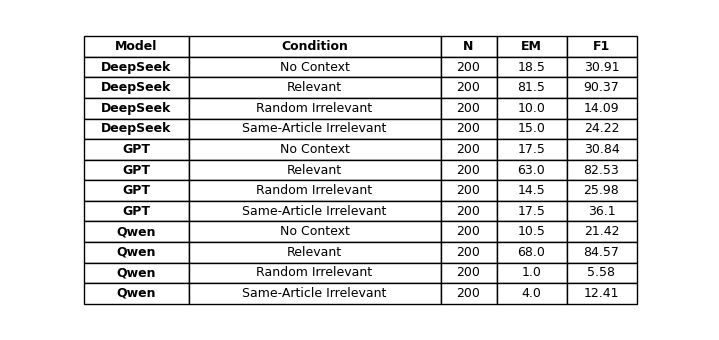

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    "Model": [
        "DeepSeek", "DeepSeek", "DeepSeek", "DeepSeek",
        "GPT", "GPT", "GPT", "GPT",
        "Qwen", "Qwen", "Qwen", "Qwen"
    ],

    "Condition": [
        "No Context",
        "Relevant",
        "Random Irrelevant",
        "Same-Article Irrelevant",

        "No Context",
        "Relevant",
        "Random Irrelevant",
        "Same-Article Irrelevant",

        "No Context",
        "Relevant",
        "Random Irrelevant",
        "Same-Article Irrelevant"
    ],

    "N": [200] * 12,

    "EM": [
        18.5, 81.5, 10.0, 15.0,
        17.5, 63.0, 14.5, 17.5,
        10.5, 68.0, 1.0, 4.0
    ],

    "F1": [
        30.91, 90.37, 14.09, 24.22,
        30.84, 82.53, 25.98, 36.10,
        21.42, 84.57, 5.58, 12.41
    ]
}

df = pd.DataFrame(data)

# Very compact figure
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.axis("off")

table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    cellLoc="center",
    colLoc="center",
    loc="center",

    # Less horizontal space
    colWidths=[0.15, 0.36, 0.08, 0.10, 0.10]
)

table.auto_set_font_size(False)
table.set_fontsize(9)

# Smaller row spacing
table.scale(1, 0.95)

# Header
for col in range(len(df.columns)):
    table[(0, col)].set_text_props(
        weight="bold",
        fontsize=9
    )

# Bold model names
for row in range(1, len(df) + 1):
    table[(row, 0)].set_text_props(weight="bold")

# Very small margins
plt.subplots_adjust(
    left=0,
    right=1,
    top=1,
    bottom=0
)

# Export
plt.savefig(
    "/content/drive/MyDrive/poster presentation/compact_results_table.png",
    dpi=400,
    bbox_inches="tight",
    pad_inches=0.01
)

plt.show()

In [ ]:
def add_f1_change(summary):

    summary = summary.copy()

    baseline = summary.loc[
        summary["condition"] == "no_context",
        "F1"
    ].iloc[0]

    summary["F1_Change_vs_No_Context"] = (
        summary["F1"] - baseline
    )

    return summary


qwen_change = add_f1_change(qwen_summary)
gpt_change = add_f1_change(gpt_summary)
deepseek_change = add_f1_change(deepseek_summary)


f1_change_summary = pd.concat(
    [
        qwen_change,
        gpt_change,
        deepseek_change
    ],
    ignore_index=True
)

f1_change_summary = f1_change_summary.round(2)

display(
    f1_change_summary[
        [
            "Model",
            "condition",
            "F1",
            "F1_Change_vs_No_Context"
        ]
    ]
)

,Model,condition,F1,F1_Change_vs_No_Context
0,Qwen,no_context,21.42,0.00
1,Qwen,random_irrelevant,5.58,-15.84
2,Qwen,relevant_context,84.57,63.15
3,Qwen,same_article_irrelevant,12.41,-9.01
4,GPT,no_context,30.84,0.00
5,GPT,random_irrelevant,25.98,-4.86
6,GPT,relevant_context,82.53,51.69
7,GPT,same_article_irrelevant,36.10,5.26
8,DeepSeek,no_context,30.91,0.00
9,DeepSeek,random_irrelevant,14.09,-16.81


### <b> Analysis:- </b>
Relevant context produced large F1 gains for all models: +63.15 (Qwen), +51.69 (GPT), and +59.46 (DeepSeek). Random irrelevant context reduced F1 by −15.84, −4.86, and −16.81, respectively. Same-article irrelevant context reduced F1 for Qwen (−9.01) and DeepSeek (−6.68), while GPT showed an increase of +5.26.

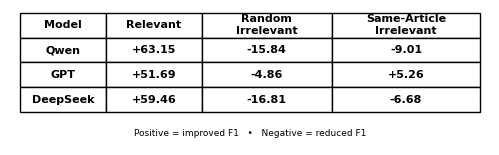

Saved to: /content/drive/MyDrive/poster presentation/f1_change_final_compact.png


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Exact values from your final experimental output
f1_change = pd.DataFrame({
    "Model": ["Qwen", "GPT", "DeepSeek"],
    "Relevant": ["+63.15", "+51.69", "+59.46"],
    "Random\nIrrelevant": ["-15.84", "-4.86", "-16.81"],
    "Same-Article\nIrrelevant": ["-9.01", "+5.26", "-6.68"]
})

# Very compact figure
fig, ax = plt.subplots(figsize=(4.8, 1.35))
ax.axis("off")

table = ax.table(
    cellText=f1_change.values,
    colLabels=f1_change.columns,
    cellLoc="center",
    colLoc="center",
    loc="upper center",
    colWidths=[0.18, 0.20, 0.27, 0.31]
)

table.auto_set_font_size(False)
table.set_fontsize(8)

# Compact rows
table.scale(1, 1.15)

# Header
for col in range(len(f1_change.columns)):
    table[(0, col)].set_text_props(
        weight="bold",
        fontsize=8
    )

# Model names
for row in range(1, 4):
    table[(row, 0)].set_text_props(
        weight="bold",
        fontsize=8
    )

# Values
for row in range(1, 4):
    for col in range(1, 4):
        table[(row, col)].set_text_props(
            weight="bold",
            fontsize=8
        )

# Put explanation DIRECTLY under the table
ax.text(
    0.5,
    0.12,
    "Positive = improved F1   •   Negative = reduced F1",
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=6.5
)

# Remove outside whitespace
plt.subplots_adjust(
    left=0,
    right=1,
    top=1,
    bottom=0
)

# Save
output_path = "/content/drive/MyDrive/poster presentation/f1_change_final_compact.png"

plt.savefig(
    output_path,
    dpi=500,
    bbox_inches="tight",
    pad_inches=0.005
)

plt.show()

print("Saved to:", output_path)

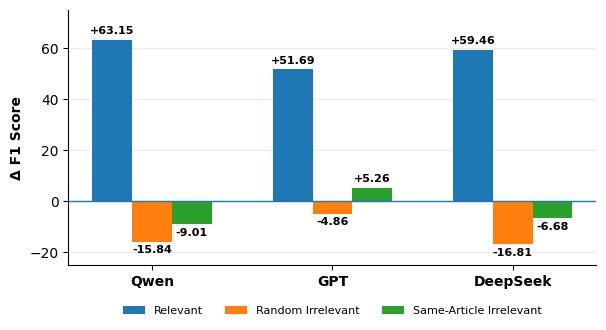

Saved to: /content/drive/MyDrive/poster presentation/f1_changes_graphical.png


In [ ]:
#graphical representation of above data
import matplotlib.pyplot as plt
import numpy as np


models = ["Qwen", "GPT", "DeepSeek"]

relevant = [63.15, 51.69, 59.46]
random_irrelevant = [-15.84, -4.86, -16.81]
same_article_irrelevant = [-9.01, 5.26, -6.68]



x = np.arange(len(models))
width = 0.22

# Compact figure suitable for poster
fig, ax = plt.subplots(figsize=(6.0, 3.4))


bars1 = ax.bar(
    x - width,
    relevant,
    width,
    label="Relevant"
)

bars2 = ax.bar(
    x,
    random_irrelevant,
    width,
    label="Random Irrelevant"
)

bars3 = ax.bar(
    x + width,
    same_article_irrelevant,
    width,
    label="Same-Article Irrelevant"
)

# Zero baseline
ax.axhline(0, linewidth=1)


def add_labels(bars):
    for bar in bars:
        value = bar.get_height()

        # Position labels above positive bars
        # and below negative bars
        if value >= 0:
            y = value + 1.5
            va = "bottom"
        else:
            y = value - 1.5
            va = "top"

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            y,
            f"{value:+.2f}",
            ha="center",
            va=va,
            fontsize=8,
            fontweight="bold"
        )

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)


ax.set_ylabel("Δ F1 Score", fontsize=10, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(
    models,
    fontsize=10,
    fontweight="bold"
)

# Same useful range as your example
ax.set_ylim(-25, 75)

# Light horizontal grid
ax.yaxis.grid(True, alpha=0.25)
ax.set_axisbelow(True)

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=3,
    frameon=False,
    fontsize=8
)

# Keep chart compact
plt.subplots_adjust(
    left=0.11,
    right=0.99,
    top=0.98,
    bottom=0.23
)



output_path = "/content/drive/MyDrive/poster presentation/f1_changes_graphical.png"

plt.savefig(
    output_path,
    dpi=500,
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()

print("Saved to:", output_path)

In [ ]:
def f1_change_analysis(results, irrelevant_condition):

    by_id = {}

    for result in results:

        question_id = result["id"]

        if question_id not in by_id:
            by_id[question_id] = {}

        by_id[question_id][
            result["condition"]
        ] = result


    analysis = []

    for question_id, conditions in by_id.items():

        if (
            "no_context" not in conditions
            or irrelevant_condition not in conditions
        ):
            continue

        baseline = conditions["no_context"]
        irrelevant = conditions[
            irrelevant_condition
        ]

        baseline_f1 = baseline["f1"]
        irrelevant_f1 = irrelevant["f1"]

        change = (
            irrelevant_f1
            - baseline_f1
        )

        if change < -1e-9:
            outcome = "Hurt"

        elif change > 1e-9:
            outcome = "Helped"

        else:
            outcome = "No Change"


        analysis.append({
            "id": question_id,
            "no_context_f1": baseline_f1,
            "irrelevant_f1": irrelevant_f1,
            "f1_change": change,
            "outcome": outcome
        })

    return analysis

In [ ]:
def hurt_help_summary(
    results,
    model_name,
    condition
):

    analysis = f1_change_analysis(
        results,
        condition
    )

    total = len(analysis)

    hurt = sum(
        x["outcome"] == "Hurt"
        for x in analysis
    )

    helped = sum(
        x["outcome"] == "Helped"
        for x in analysis
    )

    unchanged = sum(
        x["outcome"] == "No Change"
        for x in analysis
    )

    mean_change = sum(
        x["f1_change"]
        for x in analysis
    ) / total


    return {
        "Model": model_name,
        "Condition": condition,
        "N": total,

        "Hurt": hurt,
        "Hurt_%": hurt / total * 100,

        "Helped": helped,
        "Helped_%": helped / total * 100,

        "No_Change": unchanged,
        "No_Change_%": unchanged / total * 100,

        "Mean_F1_Change": mean_change * 100
    }

In [ ]:
hurt_help_final = pd.DataFrame([

    hurt_help_summary(
        qwen_results,
        "Qwen",
        "random_irrelevant"
    ),

    hurt_help_summary(
        qwen_results,
        "Qwen",
        "same_article_irrelevant"
    ),

    hurt_help_summary(
        gpt_results,
        "GPT",
        "random_irrelevant"
    ),

    hurt_help_summary(
        gpt_results,
        "GPT",
        "same_article_irrelevant"
    ),

    hurt_help_summary(
        deepseek_results,
        "DeepSeek",
        "random_irrelevant"
    ),

    hurt_help_summary(
        deepseek_results,
        "DeepSeek",
        "same_article_irrelevant"
    )

])

hurt_help_final = hurt_help_final.round(2)

display(hurt_help_final)

,Model,Condition,N,Hurt,Hurt_%,Helped,Helped_%,No_Change,No_Change_%,Mean_F1_Change
0,Qwen,random_irrelevant,200,73,36.5,11,5.5,116,58.0,-15.84
1,Qwen,same_article_irrelevant,200,58,29.0,28,14.0,114,57.0,-9.01
2,GPT,random_irrelevant,200,44,22.0,25,12.5,131,65.5,-4.86
3,GPT,same_article_irrelevant,200,27,13.5,57,28.5,116,58.0,5.26
4,DeepSeek,random_irrelevant,200,55,27.5,10,5.0,135,67.5,-16.81
5,DeepSeek,same_article_irrelevant,200,45,22.5,26,13.0,129,64.5,-6.68


### <b> Analysis:- </b>
Random irrelevant context hurt more questions than it helped across all models: Qwen 36.5% hurt vs. 5.5% helped, GPT 22.0% vs. 12.5%, and DeepSeek 27.5% vs. 5.0%. For same-article irrelevant context, Qwen (29.0% hurt vs. 14.0% helped) and DeepSeek (22.5% vs. 13.0%) were hurt more often, while GPT showed the opposite pattern (13.5% hurt vs. 28.5% helped

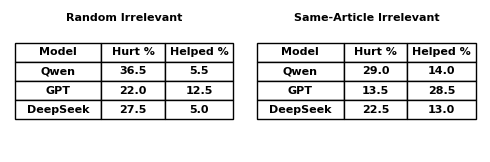

Saved to: /content/drive/MyDrive/poster presentation/hurt_help_compact.png


In [ ]:
#generating the image for hurt/hlep part
import matplotlib.pyplot as plt
import pandas as pd


random_data = pd.DataFrame({
    "Model": ["Qwen", "GPT", "DeepSeek"],
    "Hurt %": ["36.5", "22.0", "27.5"],
    "Helped %": ["5.5", "12.5", "5.0"]
})

same_article_data = pd.DataFrame({
    "Model": ["Qwen", "GPT", "DeepSeek"],
    "Hurt %": ["29.0", "13.5", "22.5"],
    "Helped %": ["14.0", "28.5", "13.0"]
})



fig = plt.figure(figsize=(4.8, 1.45))



ax1 = fig.add_axes([0.01, 0.02, 0.475, 0.98])
ax1.axis("off")

ax1.text(
    0.5, 0.98,
    "Random Irrelevant",
    transform=ax1.transAxes,
    ha="center",
    va="top",
    fontsize=8,
    fontweight="bold"
)

table1 = ax1.table(
    cellText=random_data.values,
    colLabels=random_data.columns,
    cellLoc="center",
    colLoc="center",
    loc="center",
    colWidths=[0.38, 0.28, 0.30]
)

table1.auto_set_font_size(False)
table1.set_fontsize(8)
table1.scale(1, 1.15)

# Bold headers
for col in range(3):
    table1[(0, col)].set_text_props(
        weight="bold",
        fontsize=8
    )

# Bold model names and values
for row in range(1, 4):
    table1[(row, 0)].set_text_props(
        weight="bold",
        fontsize=8
    )

    for col in range(1, 3):
        table1[(row, col)].set_text_props(
            weight="bold",
            fontsize=8
        )



ax2 = fig.add_axes([0.515, 0.02, 0.475, 0.98])
ax2.axis("off")

ax2.text(
    0.5, 0.98,
    "Same-Article Irrelevant",
    transform=ax2.transAxes,
    ha="center",
    va="top",
    fontsize=8,
    fontweight="bold"
)

table2 = ax2.table(
    cellText=same_article_data.values,
    colLabels=same_article_data.columns,
    cellLoc="center",
    colLoc="center",
    loc="center",
    colWidths=[0.38, 0.28, 0.30]
)

table2.auto_set_font_size(False)
table2.set_fontsize(8)
table2.scale(1, 1.15)

# Bold headers
for col in range(3):
    table2[(0, col)].set_text_props(
        weight="bold",
        fontsize=8
    )

# Bold model names and values
for row in range(1, 4):
    table2[(row, 0)].set_text_props(
        weight="bold",
        fontsize=8
    )

    for col in range(1, 3):
        table2[(row, col)].set_text_props(
            weight="bold",
            fontsize=8
        )




output_path = "/content/drive/MyDrive/poster presentation/hurt_help_compact.png"

plt.savefig(
    output_path,
    dpi=500,
    bbox_inches="tight",
    pad_inches=0.005
)

plt.show()

print("Saved to:", output_path)

In [ ]:
def unchanged_composition(
    results,
    model_name,
    condition
):

    analysis = f1_change_analysis(
        results,
        condition
    )

    unchanged = [
        x for x in analysis
        if x["outcome"] == "No Change"
    ]

    zero_zero = 0
    perfect_perfect = 0
    partial_same = 0


    for x in unchanged:

        before = x["no_context_f1"]
        after = x["irrelevant_f1"]

        if before == 0 and after == 0:
            zero_zero += 1

        elif before == 1 and after == 1:
            perfect_perfect += 1

        else:
            partial_same += 1


    total = len(unchanged)

    return {
        "Model": model_name,
        "Condition": condition,
        "No_Change_Total": total,

        "Zero_to_Zero": zero_zero,
        "Zero_to_Zero_%":
            zero_zero / total * 100
            if total else 0,

        "Perfect_to_Perfect":
            perfect_perfect,

        "Perfect_to_Perfect_%":
            perfect_perfect / total * 100
            if total else 0,

        "Partial_to_Same":
            partial_same,

        "Partial_to_Same_%":
            partial_same / total * 100
            if total else 0
    }

In [ ]:
unchanged_final = pd.DataFrame([

    unchanged_composition(
        qwen_results,
        "Qwen",
        "random_irrelevant"
    ),

    unchanged_composition(
        qwen_results,
        "Qwen",
        "same_article_irrelevant"
    ),

    unchanged_composition(
        gpt_results,
        "GPT",
        "random_irrelevant"
    ),

    unchanged_composition(
        gpt_results,
        "GPT",
        "same_article_irrelevant"
    ),

    unchanged_composition(
        deepseek_results,
        "DeepSeek",
        "random_irrelevant"
    ),

    unchanged_composition(
        deepseek_results,
        "DeepSeek",
        "same_article_irrelevant"
    )

])

unchanged_final = unchanged_final.round(2)

display(unchanged_final)

,Model,Condition,No_Change_Total,Zero_to_Zero,Zero_to_Zero_%,Perfect_to_Perfect,Perfect_to_Perfect_%,Partial_to_Same,Partial_to_Same_%
0,Qwen,random_irrelevant,116,112,96.55,2,1.72,2,1.72
1,Qwen,same_article_irrelevant,114,103,90.35,6,5.26,5,4.39
2,GPT,random_irrelevant,131,88,67.18,25,19.08,18,13.74
3,GPT,same_article_irrelevant,116,70,60.34,28,24.14,18,15.52
4,DeepSeek,random_irrelevant,135,107,79.26,18,13.33,10,7.41
5,DeepSeek,same_article_irrelevant,129,92,71.32,23,17.83,14,10.85
